In [3]:
!pip install boruta -q

In [4]:
# ==========================================
# 1. IMPORTS & DATA LOADING
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# ML, Preprocessing, and Feature Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Deep Learning Libraries (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

# Load dataset directly from uploaded Colab files
dataset = pd.read_csv("heart.csv")

# ==========================================
# 🚨 CRITICAL FIX: DROP DUPLICATES 🚨
# ==========================================
# The 1025-row dataset contains hundreds of duplicate rows.
# We must drop them to prevent Data Leakage and 100% memorization.
dataset = dataset.drop_duplicates()

print("✅ Libraries imported and Dataset loaded successfully!")
print(f"Dataset Shape after dropping duplicates: {dataset.shape}") # Should be ~302 rows
dataset.head()

✅ Libraries imported and Dataset loaded successfully!
Dataset Shape after dropping duplicates: (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
## 2. Comprehensive Exploratory Data Analysis (EDA)
## Before establishing the neural network architecture, we perform univariate and bivariate analysis to understand feature distributions and interactions with the target variable.

Generating Comprehensive Visualizations...


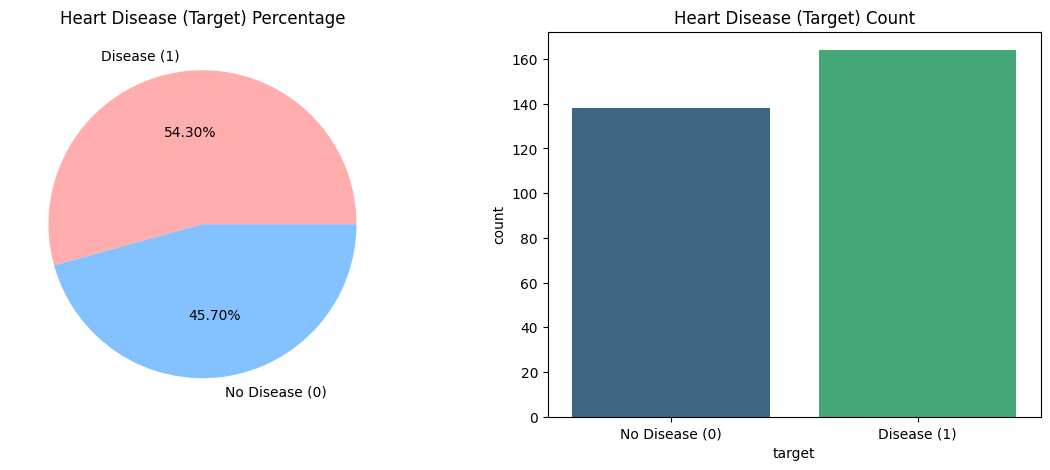

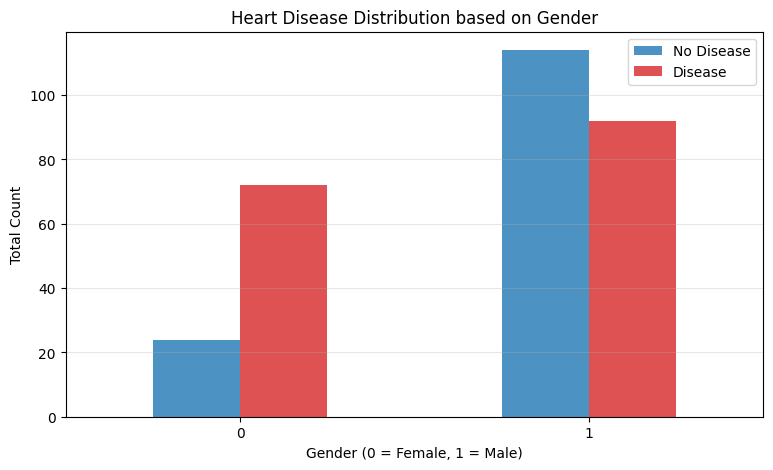

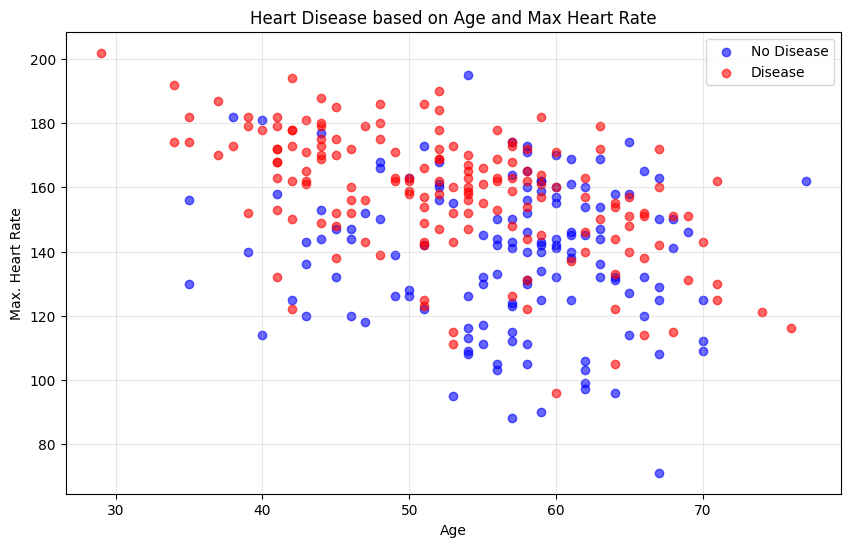

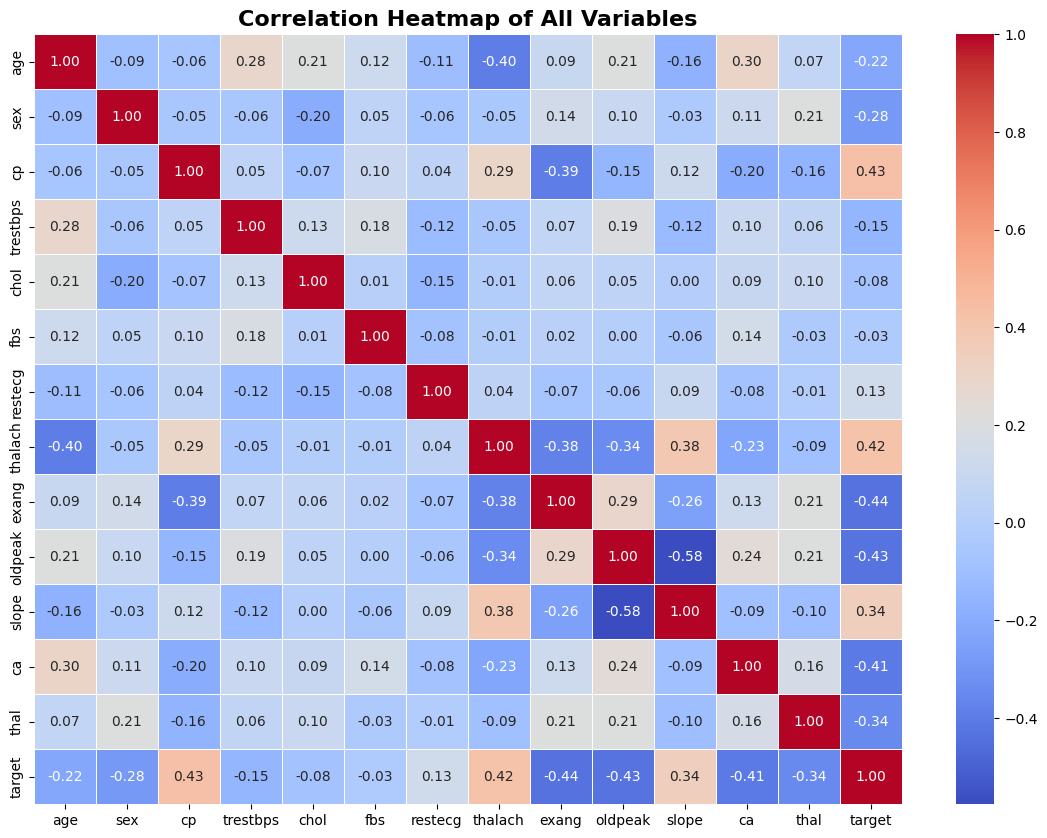

In [6]:
# ==========================================
# 2. DATA VISUALIZATIONS (EDA)
# ==========================================
print("Generating Comprehensive Visualizations...")

# 1. Target Variable Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(dataset['target'].value_counts(), labels=['Disease (1)', 'No Disease (0)'], autopct='%.2f%%', wedgeprops=dict(alpha=0.8), colors=['#ff9999','#66b3ff'])
axes[0].set_title('Heart Disease (Target) Percentage')
sns.countplot(x='target', data=dataset, ax=axes[1], palette='viridis')
axes[1].set_title('Heart Disease (Target) Count')
axes[1].set_xticklabels(['No Disease (0)', 'Disease (1)'])
plt.show()

# 2. Disease Distribution by Gender
pd.crosstab(dataset.sex, dataset.target).plot(kind='bar', figsize=(9, 5), color=['#1f77b4', '#d62728'], alpha=0.8)
plt.title('Heart Disease Distribution based on Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Total Count')
plt.legend(['No Disease', 'Disease'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Scatter Plot: Age vs Max Heart Rate
plt.figure(figsize=(10, 6))
plt.scatter(x=dataset.age[dataset.target==0], y=dataset.thalach[(dataset.target==0)], c='blue', alpha=0.6, label='No Disease')
plt.scatter(x=dataset.age[dataset.target==1], y=dataset.thalach[(dataset.target==1)], c='red', alpha=0.6, label='Disease')
plt.title('Heart Disease based on Age and Max Heart Rate')
plt.xlabel('Age')
plt.ylabel('Max. Heart Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of All Variables', fontsize=16, fontweight='bold')
plt.show()

In [7]:
## 3. Feature Selection (Boruta Wrapper Method)
# To prevent the neural network from learning noise, we use Boruta. It creates randomized "shadow features" and trains a Random Forest. Features that do not perform significantly better than their randomized shadow counterparts are rejected.

In [8]:
# ==========================================
# 3. FEATURE SELECTION (BORUTA)
# ==========================================
print("Running Boruta Feature Selection Pipeline...")
X_base = dataset.iloc[:, :-1].values
y_base = dataset.iloc[:, -1].values

# Initialize Random Forest and Boruta wrapper
forest = RandomForestClassifier(n_estimators=50, n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
feat_selector = BorutaPy(forest, n_estimators='auto', verbose=0, random_state=42)

# Fit Boruta
feat_selector.fit(X_base, y_base)

most_important = dataset.columns[:-1][feat_selector.support_].tolist()
print(f"Statistically Significant Features: {most_important}")

# Drop features rejected by Boruta (restecg, fbs)
dataset1 = dataset.drop(columns=["restecg", "fbs"])
print(f"Refined Dataset Shape: {dataset1.shape}")

Running Boruta Feature Selection Pipeline...
Statistically Significant Features: ['age', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Refined Dataset Shape: (302, 12)


In [9]:
# ==========================================
# 4. PREPROCESSING & TENSOR RESHAPING
# ==========================================
cate_val = [col for col in dataset1.columns if dataset1[col].nunique() <= 10 and col not in ['sex', 'target']]
cont_val = [col for col in dataset1.columns if dataset1[col].nunique() > 10]

# 1. One-Hot Encoding (Force dtype to float32 to prevent TF errors)
dataset1 = pd.get_dummies(dataset1, columns=cate_val, drop_first=True, dtype='float32')

X = dataset1.drop('target', axis=1)
y = dataset1['target']

# Save expected columns for the frontend
expected_columns = X.columns.tolist()
pickle.dump(expected_columns, open('expected_columns.pkl', 'wb'))

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. Feature Scaling
st = StandardScaler()
X_train[cont_val] = st.fit_transform(X_train[cont_val])
X_test[cont_val] = st.transform(X_test[cont_val])

# Save scaler for the frontend
pickle.dump(st, open('scaler.pkl', 'wb'))

# 4. EXPLICITLY convert to float32 and Reshape into 3D Tensors for the CNN
X_train_cnn = np.asarray(X_train).astype('float32').reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = np.asarray(X_test).astype('float32').reshape((X_test.shape[0], X_test.shape[1], 1))

# Also ensure targets are floats for binary crossentropy loss
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

print(f" Training Tensor Shape: {X_train_cnn.shape}")
print(f"Testing Tensor Shape: {X_test_cnn.shape}")

 Training Tensor Shape: (241, 19, 1)
Testing Tensor Shape: (61, 19, 1)


Initializing the Deep Learning Architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 32)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,785 (73.38 KB)

 Trainable params: 18,721 (73.13 KB)

 Non-trainable params: 64 (256.00 B)


--- Training the CNN ---
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6763 - loss: 0.6368 - val_accuracy: 0.7869 - val_loss: 0.6158
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8465 - loss: 0.3684 - val_accuracy: 0.8033 - val_loss: 0.5942
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8423 - loss: 0.4115 - val_accuracy: 0.8033 - val_loss: 0.5783
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8755 - loss: 0.3252 - val_accuracy: 0.8197 - val_loss: 0.5729
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8340 - loss: 0.3575 - val_accuracy: 0.8197 - val_loss: 0.5632
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8506 - loss: 0.3502 - val_accuracy: 0.8033 - val_loss: 0.5497
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8506 - loss: 0.3186 - val_accuracy: 0.8033 - val_loss: 0.5411
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8963 - loss: 0.2844 - val_a

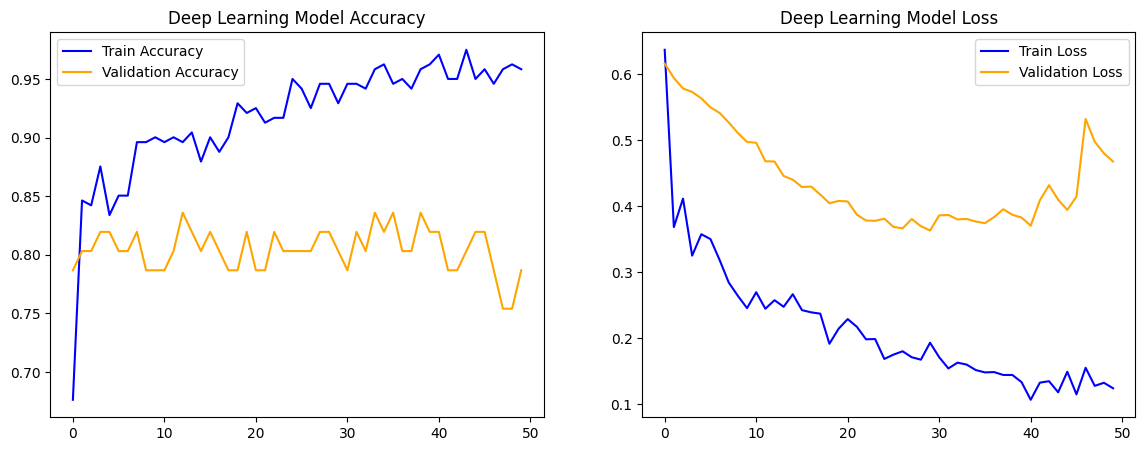

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step

--- Model Performance Metrics ---
Testing Accuracy: 78.69%

Confusion Matrix:
 [[19  6]
 [ 7 29]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      0.76      0.75        25
         1.0       0.83      0.81      0.82        36

    accuracy                           0.79        61
   macro avg       0.78      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61


Pipeline Complete: 'cnn_heart_model.keras' generated successfully.


In [10]:
# ==========================================
# 5. MODEL TRAINING & EVALUATION
# ==========================================
print("Initializing the Deep Learning Architecture...")

model = Sequential()

# Feature Extraction Layer
model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Flatten for Dense classification
model.add(Flatten())

# Fully Connected Layer with Regularization
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4)) # Crucial for preventing 100% memorization

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

print("\n--- Training the CNN ---")
history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_cnn, y_test),
    verbose=1 # Prints every single epoch
)

# Plotting the Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Deep Learning Model Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Deep Learning Model Loss')
axes[1].legend()
plt.show()

# Final Predictions
y_pred_probs = model.predict(X_test_cnn)
y_pred = (y_pred_probs > 0.5).astype(int)

print(f"\n--- Model Performance Metrics ---")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save the Keras model
model.save('cnn_heart_model.keras')
print("\nPipeline Complete: 'cnn_heart_model.keras' generated successfully.")